In [1]:
# # Netflix Movies and TV Shows EDA Project

# ## Project Objective

# The objective of this project is to analyze the Netflix Movies and TV Shows dataset using Python, Pandas, Matplotlib, and Seaborn.
# We will clean the data, explore patterns, create visualizations, and generate business insights based on Netflix content trends.

In [2]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("/content/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# ## Dataset Summary

# 1. This dataset contains information about movies and TV shows available on Netflix.
# 2. It includes details such as title, director, cast, country, release year, rating, duration, and genre.
# 3. The dataset contains both Movies and TV Shows.
# 4. Some columns have missing values, especially director, cast, country, and date_added.
# 5. This dataset can help us understand Netflix's content distribution, popular genres, country-wise content, and yearly growth trends.

In [ ]:
# ## Data Cleaning

# In this step, we handle missing values, remove duplicates, and prepare the dataset for analysis.

In [12]:
#check missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) *100
missing_percentage.sort_values(ascending=False)

,0
director,29.908028
country,9.435676
cast,9.367549
date_added,0.113546
rating,0.045418
duration,0.034064
show_id,0.000000
type,0.000000
title,0.000000
release_year,0.000000


In [13]:
#filling of missing values in the important columns
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)
df['duration'].fillna("Unknown",inplace = True)
#dropping rows where date_added has missing values for time based analysis
df.dropna(subset=['date_added'], inplace=True)

#remove duplicates if present any
df = df.drop_duplicates()

/tmp/ipykernel_4430/3218033040.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_4430/3218033040.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [26]:
#convert date added to date time
df['date_added'] = pd.to_datetime(df['date_added'],errors = 'coerce')

#create new columns for year and month added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


In [27]:
df['date_added'].isnull().sum()

np.int64(0)

In [28]:
df = df.dropna(subset = "date_added")

In [32]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [34]:
# # Exploratory Data Analysis

# In this section, we will answer five important questions about Netflix content using Pandas.

In [35]:
#How many movies and TV shows are available on the Netflix?
content_type_counts = df['type'].value_counts()
print(content_type_counts)

type
Movie      6131
TV Show    2578
Name: count, dtype: int64


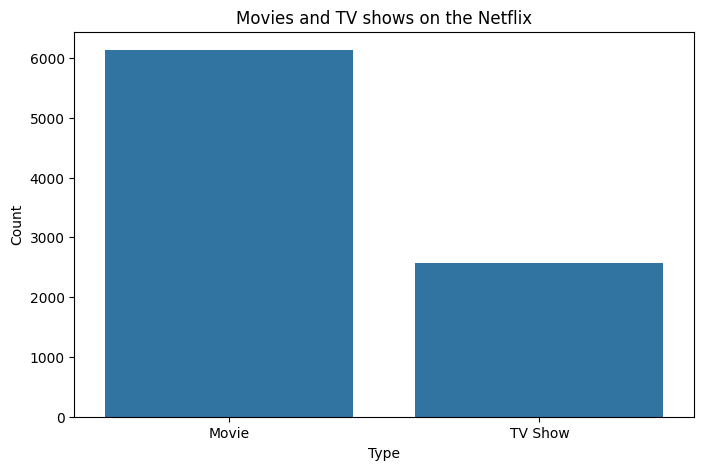

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='type')
plt.title("Movies and TV shows on the Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Netflix has more Movies than TV Shows, which shows that movie content forms the major part of Netflix's catalog.


In [ ]:
# ### Q1 Result: Movies vs TV Shows

# Netflix has 6,131 Movies and 2,578 TV Shows in the cleaned dataset.
# This shows that Netflix's catalog is heavily focused on Movies compared to TV Shows.

In [38]:
#which are the Top 10 countries Producing the Netflix content
top_countries = df['country'].value_counts().head(10)
top_countries

,count
country,
United States,2778
India,971
Unknown,827
United Kingdom,403
Japan,241
South Korea,195
Canada,173
Spain,141
France,122


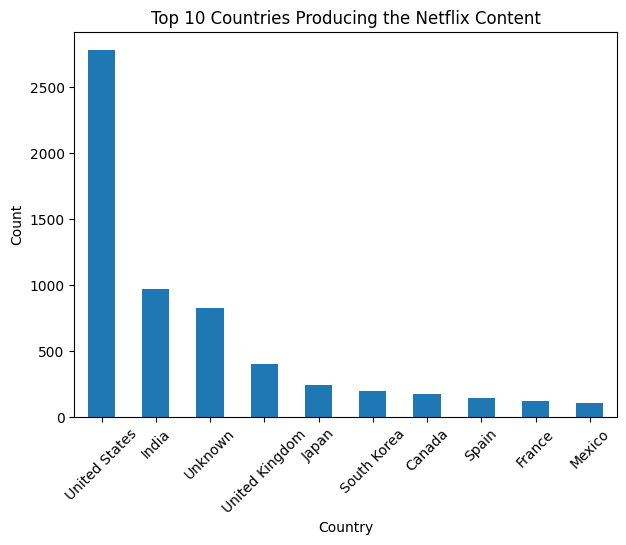

In [40]:
plt.figure(figsize=(7,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing the Netflix Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.show()


In [ ]:
# ### Q5 Result: Top Countries Producing Netflix Content

# The country-wise analysis shows which countries contribute the highest number of titles to Netflix.
# This helps us understand Netflix's strongest content markets and production regions.

In [42]:
#In which year the netflix add the most content?
content_by_year = df['year_added'].value_counts().sort_index()
content_by_year

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,10
2014,23
2015,73
2016,418


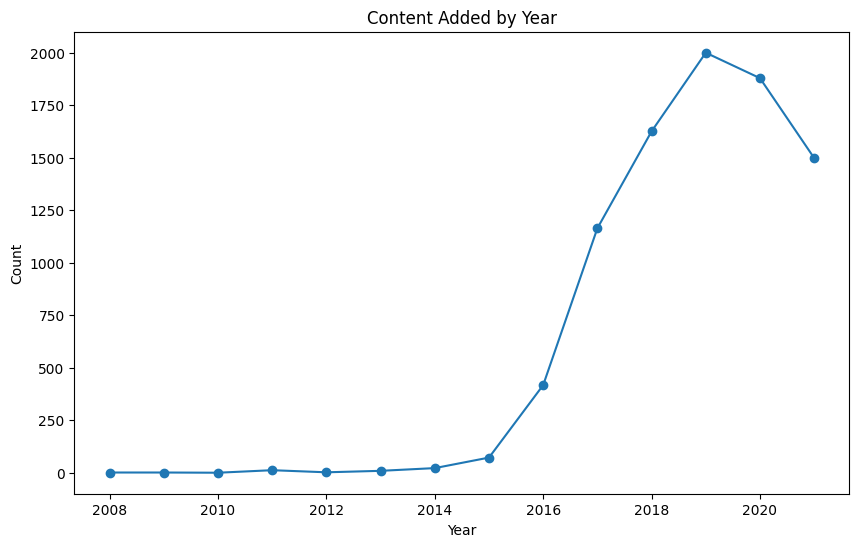

In [43]:
plt.figure(figsize=(10,6))
content_by_year.plot(kind='line',marker='o')
plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [ ]:
# ### Q2 Result: Content Added Over the Years

# Netflix added very few titles before 2015.
# A major increase started from 2016, and the highest number of titles were added in 2019 with 1,999 titles.
# # After 2019, the number slightly decreased in 2020 and 2021.

In [44]:
#what are the Top 10 most common categories
genres = df['listed_in'].str.split(', ', expand=True).stack()
top_genres = genres.value_counts().head(10)
top_genres

,count
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1328
Documentaries,869
Action & Adventure,859
Independent Movies,756
TV Dramas,739
Children & Family Movies,641
Romantic Movies,616


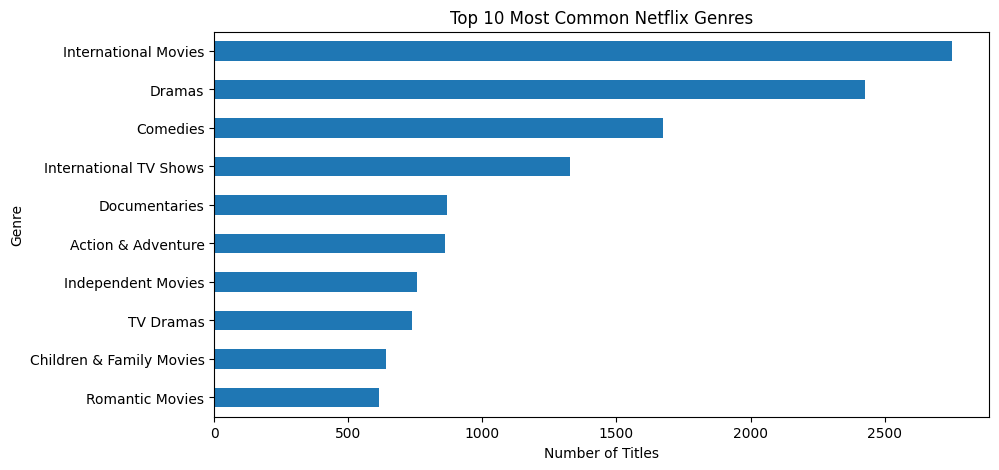

In [45]:
plt.figure(figsize=(10,5))
top_genres.plot(kind='barh')
plt.title('Top 10 Most Common Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# ### Q3 Result: Top Netflix Genres

# The most common genre on Netflix is International Movies with 2,752 titles.
# This is followed by Dramas with 2,427 titles and Comedies with 1,674 titles.
# This shows that Netflix has a strong focus on international and drama-based content.

In [46]:
#What are the most common ratings on Netflix?
rating_count = df['rating'].value_counts().head(10)
rating_count

,count
rating,
TV-MA,3183
TV-14,2133
TV-PG,838
R,799
PG-13,490
TV-Y7,330
TV-Y,300
PG,287
TV-G,212


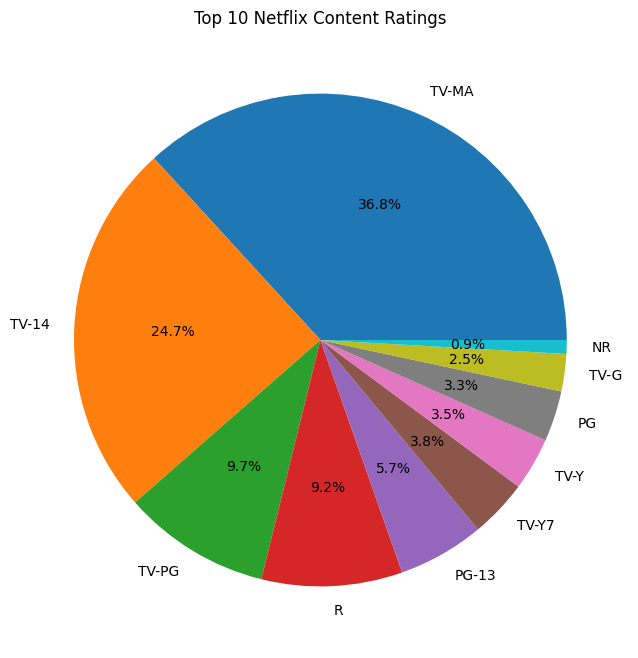

In [47]:
plt.figure(figsize=(8,8))
rating_count.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Netflix Content Ratings')
plt.ylabel('')
plt.show()

In [ ]:
# ### Q4 Result: Most Common Ratings

# The most common rating on Netflix is TV-MA with 3,183 titles, followed by TV-14 with 2,133 titles.
# This suggests that a large portion of Netflix content is targeted toward mature and teenage audiences.

In [48]:
#separating movie shows from tv show seasons
df['duration_number'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_type'] = df['duration'].str.extract('([a-zA-Z]+)')
df[['duration', 'duration_number', 'duration_type']].head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_4430/1250951545.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['duration_number'] = df['duration'].str.extract('(\d+)').astype(float)


,duration,duration_number,duration_type
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons


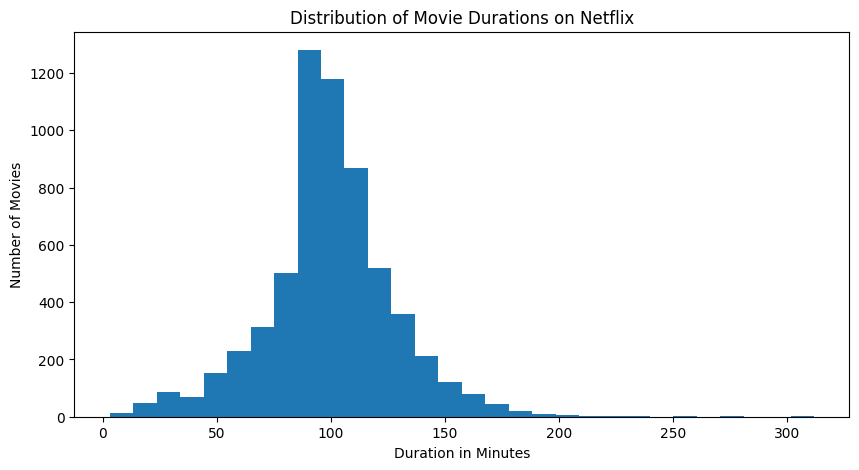

In [49]:
movies = df[df['type'] == 'Movie']

plt.figure(figsize=(10,5))
plt.hist(movies['duration_number'].dropna(), bins=30)
plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration in Minutes')
plt.ylabel('Number of Movies')
plt.show()

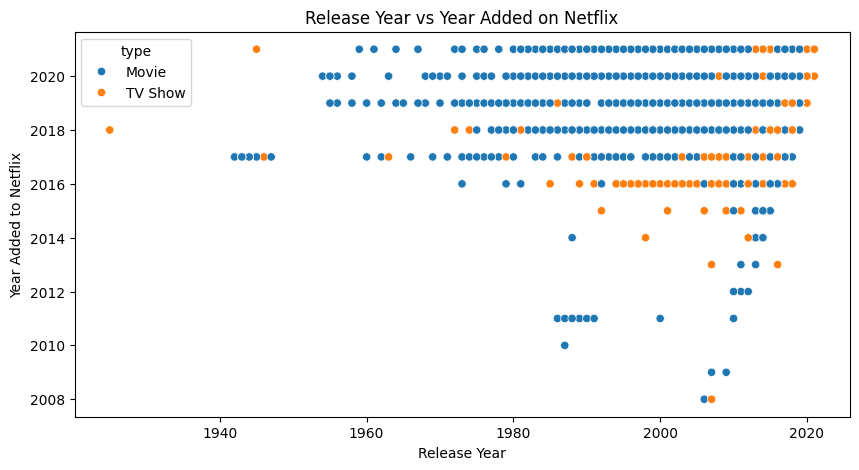

In [50]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='release_year', y='year_added', hue='type')
plt.title('Release Year vs Year Added on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Year Added to Netflix')
plt.show()

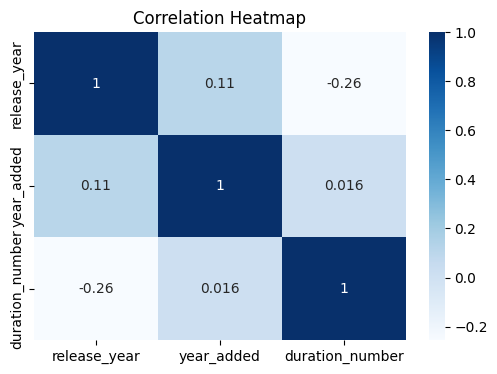

In [51]:
numeric_cols = df[['release_year', 'year_added', 'duration_number']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()


In [52]:
# # Final Insights Report

# 1. Netflix has more Movies than TV Shows. The dataset contains 6,131 Movies and 2,578 TV Shows, showing that Movies form the largest part of Netflix's content catalog.

# 2. Netflix content increased rapidly after 2016. The highest number of titles were added in 2019, with 1,999 titles added in that year.

# 3. International Movies are the most common genre on Netflix, with 2,752 titles. This shows Netflix's strong focus on global content and international audiences.

# 4. Dramas and Comedies are also highly popular categories, with 2,427 Drama titles and 1,674 Comedy titles. This suggests that entertainment and story-driven content are important parts of Netflix's strategy.

# 5. TV-MA is the most common rating, with 3,183 titles, followed by TV-14 with 2,133 titles. This indicates that Netflix has a large amount of content targeted toward mature and teenage viewers.

In [54]:
# # Most Surprising Finding

# The most surprising finding was that International Movies are the most common genre on Netflix.
# This shows that Netflix is not only focused on local or US-based content, but also invests heavily in global content for worldwide audiences.